In [ ]:
import torch
import time

# 1. Setup Devices
if not torch.backends.mps.is_available():
    print("MPS not available. Check your PyTorch installation.")
    device_gpu = torch.device("cpu") # Fallback
else:
    device_gpu = torch.device("mps")
    print("M1 GPU (MPS) detected!")

device_cpu = torch.device("cpu")

# 2. Create large random matrices (Size 5000x5000)
# This simulates heavy neural network weights
size = 5000
print(f"Testing with {size}x{size} matrices...")

# CPU Benchmark
x_cpu = torch.randn(size, size, device=device_cpu)
y_cpu = torch.randn(size, size, device=device_cpu)

start_cpu = time.time()
result_cpu = torch.matmul(x_cpu, y_cpu)
end_cpu = time.time() - start_cpu
print(f"CPU Execution Time: {end_cpu:.4f} seconds")

# GPU (MPS) Benchmark
x_gpu = torch.randn(size, size, device=device_gpu)
y_gpu = torch.randn(size, size, device=device_gpu)

# "Warm-up" run (GPU initialization often takes a second)
_ = torch.matmul(x_gpu, y_gpu)

start_gpu = time.time()
result_gpu = torch.matmul(x_gpu, y_gpu)

# Wait for the GPU to finish its task (asynchronous execution)
torch.mps.synchronize() 

end_gpu = time.time() - start_gpu
print(f"M1 GPU Execution Time: {end_gpu:.4f} seconds")

# 3. Calculate Speedup
speedup = end_cpu / end_gpu
print(f"\nYour M1 GPU is {speedup:.2f}x faster than your CPU for this task.")

In [ ]:
import sys
print(sys.executable)

In [ ]:
!pip install nilearn scikit-learn

In [ ]:
!pip install matplotlib seaborn

In [1]:
import nilearn
import sklearn
print(f"Nilearn version: {nilearn.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Nilearn version: 0.13.1
Scikit-learn version: 1.7.2


[fetch_atlas_schaefer_2018] Added README.md to /Users/uchemudiuzoka/nilearn_data
[fetch_atlas_schaefer_2018] Dataset created in /Users/uchemudiuzoka/nilearn_data/schaefer_2018
[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order.txt ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_development_fmri] Dataset created in /Users/uchemudiuzoka/nilearn_data/development_fmri
[fetch_development_fmri] Added README.md to /Use

/var/folders/r2/vylwz89s3kgggzjj7_sch5hr0000gn/T/ipykernel_25845/4138895672.py:22: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(func_file, confounds=confounds_file)
/var/folders/r2/vylwz89s3kgggzjj7_sch5hr0000gn/T/ipykernel_25845/4138895672.py:22: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(func_file, confounds=confounds_file)


Extraction Successful! Data Shape: (168, 100)


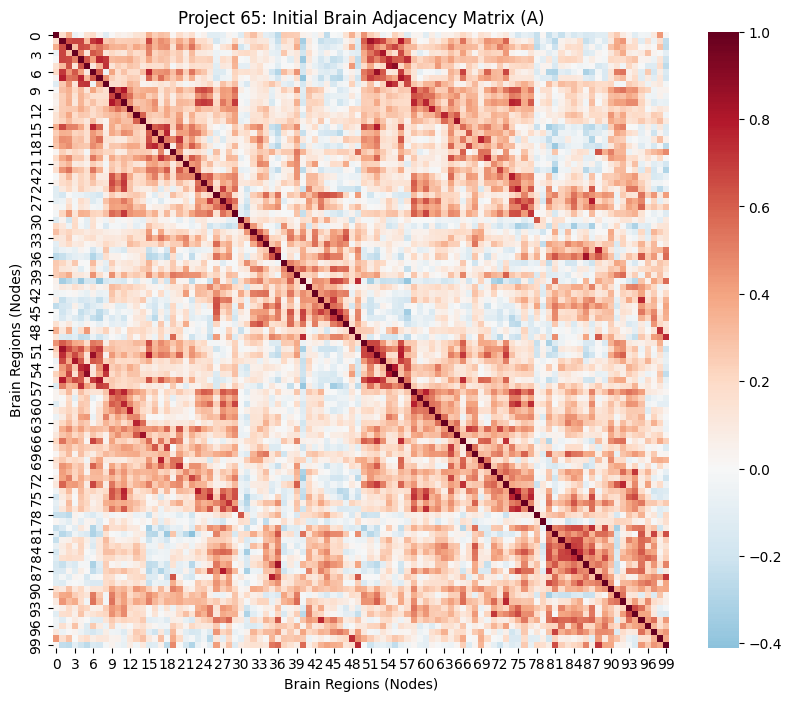

In [2]:
from nilearn import datasets, maskers # Updated from input_data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Added for better looking heatmaps

# 1. Fetch the Atlas (Nodes) and sample data
# The 'Schaefer' atlas is the one we talked about for Project 65 nodes
atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100)
data = datasets.fetch_development_fmri(n_subjects=1)
func_file = data.func[0]
confounds_file = data.confounds[0]

# 2. Use the 'Masker' (The modern way)
# This extracts the signal from the 3D MRI into a 100-column table
masker = maskers.NiftiLabelsMasker(
    labels_img=atlas.maps, 
    standardize=True, 
    memory='nilearn_cache'
)

# Extract the time series (Brain activity over time per region)
time_series = masker.fit_transform(func_file, confounds=confounds_file)
print(f"Extraction Successful! Data Shape: {time_series.shape}")

# 3. Create the Adjacency Matrix (Correlation)
# This is 'A' - the heart of your Graph Neural Network
correlation_matrix = np.corrcoef(time_series.T)

# 4. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='RdBu_r', center=0, square=True)
plt.title("Project 65: Initial Brain Adjacency Matrix (A)")
plt.xlabel("Brain Regions (Nodes)")
plt.ylabel("Brain Regions (Nodes)")
plt.show()

In [6]:
!pip install torch-geometric

  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [torch-geometric] [torch-geometric]


In [2]:
from src.models.siamese_gnn import SiameseBrainNet
import torch

# Initialize model (assuming 16 features per brain region and 64 hidden units)
model = SiameseBrainNet(num_node_features=16, hidden_channels=64)

# Create dummy twin data (GNNs expect 'Batch' indices)
from torch_geometric.data import Data, Batch
twin_a = Batch.from_data_list([Data(x=torch.randn(100, 16), edge_index=torch.randint(0, 100, (2, 300)))])
twin_b = Batch.from_data_list([Data(x=torch.randn(100, 16), edge_index=torch.randint(0, 100, (2, 300)))])

# Get the similarity distance
distance = model(twin_a, twin_b)
print(f"Initial Distance between Twins: {distance.item():.4f}")

Initial Distance between Twins: 0.3708


In [1]:
import sys
import os

# This adds the root directory (NeuroSpectral-GNN) to your path
sys.path.append(os.path.abspath(os.path.join('..')))

# Now try the import again
from src.models.siamese_gnn import SiameseBrainNet
import torch
print("Import successful!")

/Users/uchemudiuzoka/miniforge3/envs/neurognn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Import successful!


In [3]:
import torch.nn as nn

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, distance, label):
        # label = 0 for twins (MZ/DZ), 1 for unrelated
        loss = torch.mean((1 - label) * torch.pow(distance, 2) +
                          (label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2))
        return loss

# Example test:
criterion = ContrastiveLoss(margin=1.0)
mock_label = torch.tensor([0.0]) # Let's pretend they ARE twins
loss = criterion(distance, mock_label)

print(f"Current Loss for this pair: {loss.item():.4f}")

Current Loss for this pair: 0.1375
